# RAG-Based Spam Detection System using FAISS & LLMs

## Project Overview
This project implements a Retrieval-Augmented Generation (RAG) pipeline
for intelligent spam detection using semantic embeddings, FAISS vector
search, and LLM-powered reasoning.

### Features
- Semantic spam retrieval
- Vector similarity search
- FAISS indexing
- AI-generated explanations
- Spam/Ham classification
- RAG pipeline architecture

User Query

   ↓

Text Preprocessing

   ↓

Sentence Transformer Embeddings

   ↓

FAISS Vector Search

   ↓

Top-k Similar Spam Retrieval

   ↓

LLM Context Reasoning

   ↓
   
Final Spam/Ham Prediction

## Installation

```bash
pip install pandas numpy scikit-learn
pip install sentence-transformers
pip install faiss-cpu
pip install matplotlib seaborn
pip install openai


---

### Add Dataset Explanation

### Add Markdown Cell

```markdown
## Dataset Information

Dataset Used:
- Spam/Ham Email Dataset

Columns:
- label → spam or ham
- text → email/message content

Goal:
Build a semantic spam detection system using Retrieval-Augmented Generation.

In [1]:
pip install pandas faiss-cpu sentence-transformers numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 45.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('/content/spam_ham_dataset.csv')
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


## **NLP Text Preprocessing**

The raw text data is cleaned before generating embeddings.

Preprocessing steps:
- Lowercasing
- URL removal
- Email removal
- Number removal
- Punctuation removal
- Whitespace normalization

This improves semantic embedding quality and retrieval performance.

In [4]:
import re
import string
import pandas as pd

# Remove missing values
df.dropna(inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

# Text cleaning function
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Apply cleaning
df['clean_text'] = df['text'].apply(clean_text)

# Preview cleaned text
df[['text', 'clean_text']].head()

,text,clean_text
0,Subject: enron methanol ; meter # : 988291\r\n...,subject enron methanol meter this is a follow ...
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",subject hpl nom for january see attached file ...
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",subject neon retreat ho ho ho we re around to ...
3,"Subject: photoshop , windows , office . cheap ...",subject photoshop windows office cheap main tr...
4,Subject: re : indian springs\r\nthis deal is t...,subject re indian springs this deal is to book...


## **Exploratory Data Analysis (EDA)**

This section analyzes:
- Spam vs Ham distribution
- Message length patterns
- Common spam characteristics

EDA helps understand the dataset before building the RAG pipeline.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

### Spam vs Ham Distribution

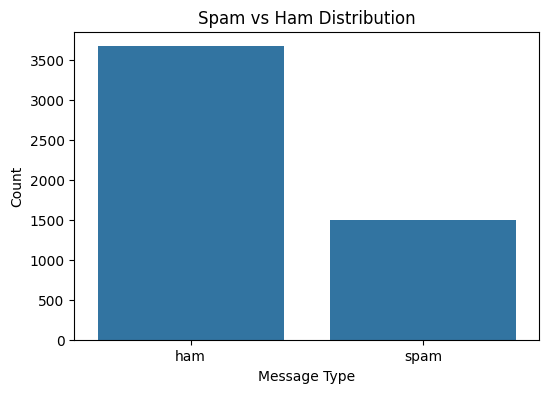

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(x='label', data=df)

plt.title("Spam vs Ham Distribution")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

### Message Length Feature

In [7]:
df['message_length'] = df['clean_text'].apply(len)

df[['clean_text', 'message_length']].head()

,clean_text,message_length
0,subject enron methanol meter this is a follow ...,279
1,subject hpl nom for january see attached file ...,67
2,subject neon retreat ho ho ho we re around to ...,2329
3,subject photoshop windows office cheap main tr...,394
4,subject re indian springs this deal is to book...,319


### Message Length Distribution

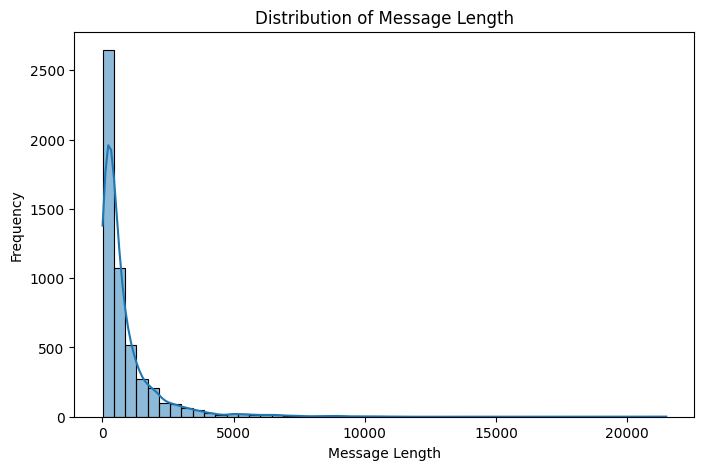

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['message_length'], bins=50, kde=True)

plt.title("Distribution of Message Length")
plt.xlabel("Message Length")
plt.ylabel("Frequency")

plt.show()

### Compare Spam vs Ham Message Length

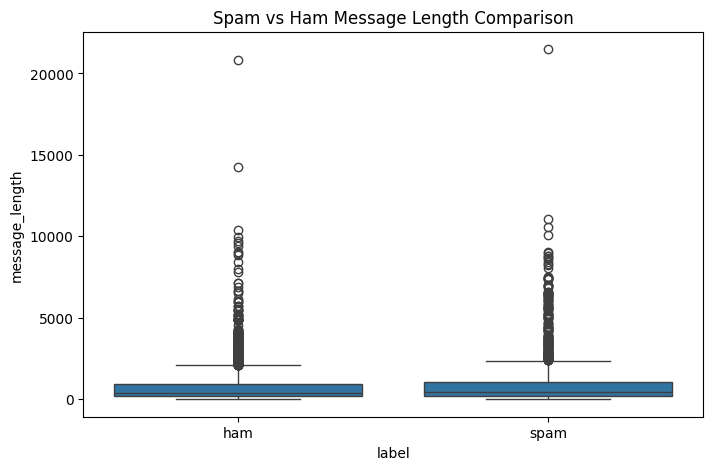

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(x='label', y='message_length', data=df)

plt.title("Spam vs Ham Message Length Comparison")

plt.show()

### Most Common Spam Words

In [10]:
from collections import Counter

spam_words = " ".join(df[df['label'] == 'spam']['clean_text']).split()

common_spam = Counter(spam_words).most_common(20)

common_spam

[('the', 7254),
 ('to', 5160),
 ('and', 4903),
 ('of', 4490),
 ('a', 3787),
 ('in', 3129),
 ('you', 2794),
 ('for', 2523),
 ('this', 2283),
 ('is', 2256),
 ('your', 1946),
 ('subject', 1657),
 ('with', 1470),
 ('that', 1348),
 ('s', 1316),
 ('be', 1303),
 ('or', 1301),
 ('on', 1259),
 ('as', 1199),
 ('are', 1167)]

### Convert Common Words into DataFrame

In [11]:
common_spam_df = pd.DataFrame(common_spam, columns=['Word', 'Count'])

common_spam_df.head()

,Word,Count
0,the,7254
1,to,5160
2,and,4903
3,of,4490
4,a,3787


### Plot Most Common Spam Words

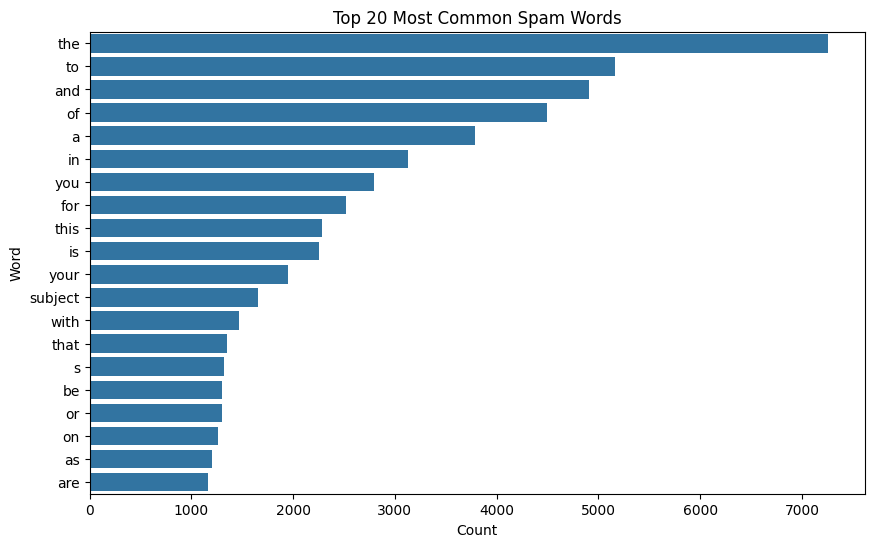

In [12]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Count',
    y='Word',
    data=common_spam_df
)

plt.title("Top 20 Most Common Spam Words")

plt.show()

### **EDA Insights**

Key observations:
- Spam messages tend to contain promotional wording.
- Spam messages are generally longer.
- Certain keywords appear frequently in spam content.
- Data preprocessing is essential before semantic embedding generation.

These insights help improve retrieval quality in the RAG pipeline.

## **Semantic Embedding Generation**

In this section, textual messages are converted into dense vector embeddings
using Sentence Transformers.

These embeddings capture semantic meaning and enable similarity-based retrieval
for the RAG pipeline.

### Install Sentence Transformers

In [13]:
!pip install sentence-transformers

### Import Required Libraries

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

### Load Embedding Model

In [ ]:
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

### Generate Embeddings

In [ ]:
embeddings = embedding_model.encode(
    df['clean_text'].tolist(),
    show_progress_bar=True
)

### Convert to NumPy Array

In [ ]:
embeddings = np.array(embeddings)

embeddings.shape

### Preview First Embedding

In [ ]:
embeddings[0]

### Add Embedding Dimension Check

In [ ]:
print("Embedding Shape:", embeddings.shape)
print("Embedding Dimension:", embeddings.shape[1])

### Why Embeddings Matter

Traditional spam detection relies on keyword matching.

Semantic embeddings allow:
- contextual understanding
- semantic similarity
- intelligent retrieval
- better generalization

Example:
- "Win cash now"
- "Claim your reward"

These may have different words but similar semantic meaning.

### Add Example Semantic Similarity Test

In [ ]:
query_1 = "Win a free iPhone today"
query_2 = "Claim your free mobile reward"

query_embeddings = embedding_model.encode([query_1, query_2])

from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(
    [query_embeddings[0]],
    [query_embeddings[1]]
)

print("Semantic Similarity:", similarity[0][0])

### Save Embeddings

In [ ]:
np.save("spam_embeddings.npy", embeddings)

### Embedding Generation Complete

The dataset has now been transformed into semantic vector representations.

These embeddings will be indexed using FAISS to enable efficient similarity
search and Retrieval-Augmented Generation (RAG).

## **FAISS Vector Database**

FAISS (Facebook AI Similarity Search) is used to efficiently store and search
high-dimensional embedding vectors.

This enables semantic retrieval of similar spam/ham messages.

### Install FAISS

In [ ]:
!pip install faiss-cpu

### Import FAISS

In [ ]:
import faiss

### Get Embedding Dimension

In [ ]:
dimension = embeddings.shape[1]

print("Embedding Dimension:", dimension)

### Create FAISS Index

In [ ]:
index = faiss.IndexFlatL2(dimension)

### Add Embeddings to FAISS Index

In [ ]:
index.add(embeddings)

### Verify Number of Stored Vectors

In [ ]:
print("Total vectors stored in FAISS index:", index.ntotal)

### Add Query Example

In [ ]:
query = "Congratulations! You won a free lottery prize"

### Convert Query into Embedding

In [ ]:
query_embedding = embedding_model.encode([query])

query_embedding = np.array(query_embedding)

### Retrieve Top-k Similar Messages

In [ ]:
top_k = 3

distances, indices = index.search(query_embedding, top_k)

### Show Retrieval Results

In [ ]:
print("Top Retrieved Messages:\n")

for i, idx in enumerate(indices[0]):

    print(f"Result {i+1}")
    print("Message:")
    print(df.iloc[idx]['text'])

    print("Label:")
    print(df.iloc[idx]['label'])

    print("Similarity Distance:")
    print(distances[0][i])

    print("-" * 50)

### Semantic Retrieval

FAISS retrieves semantically similar messages based on vector similarity.

Unlike keyword matching, semantic retrieval can identify conceptually similar
messages even if wording differs.

Example:
- "Win cash prize"
- "Claim your reward"

These messages may use different words but share similar semantic meaning.

### Add Similarity Score Interpretation

In [ ]:
for score in distances[0]:
    print("Similarity Distance:", score)

### Save FAISS Index

In [ ]:
faiss.write_index(index, "spam_faiss_index.index")

### Load FAISS Index

In [ ]:
loaded_index = faiss.read_index("spam_faiss_index.index")

### FAISS Indexing Complete

The semantic embeddings have been successfully indexed using FAISS.

The system can now:
- retrieve similar spam messages
- perform semantic search
- support Retrieval-Augmented Generation (RAG)

This forms the retrieval layer of the GenAI pipeline.

### **LLM-Powered Reasoning Layer**

This section combines:
- semantic retrieval
- contextual reasoning
- large language models (LLMs)

to generate intelligent spam detection explanations.

The retrieved messages are used as contextual knowledge for the LLM.

### Gemini API Setup (Recommended)

In [ ]:
!pip install google-generativeai

### Import Gemini

In [ ]:
import google.generativeai as genai

### Configure API Key

In [ ]:
GEMINI_API_KEY = "YOUR_API_KEY"

genai.configure(api_key=GEMINI_API_KEY)

### Load Gemini Model

In [ ]:
model = genai.GenerativeModel("gemini-1.5-flash")

### Retrieve Top-k Context Messages

### Create Query

In [ ]:
query = "Congratulations! You won a free lottery prize"

### Convert Query to Embedding

In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

In [ ]:
embeddings = embedding_model.encode(
    df['clean_text'].tolist(),
    show_progress_bar=True
)

In [ ]:
retrieved_texts = []

for idx in indices[0]:
    retrieved_texts.append(df.iloc[idx]['text'])

## **LLM-Based Reasoning with Gemini**

This section integrates Google's Gemini model with the RAG pipeline.

Retrieved contextual messages are passed to the LLM to generate:
- spam/ham predictions
- contextual explanations
- reasoning-based analysis

### Install Gemini Library

In [ ]:
!pip install google-generativeai

### Import Gemini

In [ ]:
import google.generativeai as genai

### Add Your API Key

In [ ]:
GEMINI_API_KEY = "YOUR_API_KEY"

### Configure Gemini

In [ ]:
genai.configure(api_key=GEMINI_API_KEY)

### Load Gemini Model

In [ ]:
llm_model = genai.GenerativeModel("gemini-1.5-flash")

### Create Context from Retrieved Messages

In [ ]:
context = "\n".join(retrieved_texts)

print(context)

### Create RAG Prompt Template

In [ ]:
prompt = f"""
You are an intelligent AI spam detection assistant.

User Message:
{query}

Retrieved Similar Messages:
{context}

Your Tasks:
1. Predict whether the message is Spam or Ham.
2. Explain the reasoning.
3. Mention suspicious patterns if present.
4. Provide confidence level.

Return the answer clearly.
"""

### Generate AI Response

In [ ]:
import os

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

### Display AI Output

In [ ]:
print(label.text)

### Add Professional Output Formatting

In [ ]:
print("="*70)
print("RAG-BASED SPAM DETECTION RESULT")
print("="*70)

print("\nUser Query:")
print(query)

print("\nRetrieved Context Messages:")
for i, text in enumerate(retrieved_texts):

    print(f"\nContext {i+1}:")
    print(text)

print("\n")
print("="*70)
print("LLM ANALYSIS")
print("="*70)

print(response.text)

### Add Multiple Query Testing

In [ ]:
test_queries = [
    "Win a free iPhone now",
    "Meeting tomorrow at 10 AM",
    "Claim your reward immediately"
]

for q in test_queries:
    print("\n" + "="*60)
    print("Query:", q)

### Why LLM Integration Improves Spam Detection

Traditional ML models only predict labels.

The LLM reasoning layer enables:
- contextual understanding
- explainability
- intelligent analysis
- natural language reasoning

This creates a more transparent and human-like spam detection system.

### LLM Reasoning Layer Complete

The RAG pipeline now combines:
- semantic embeddings
- FAISS retrieval
- contextual augmentation
- LLM-powered reasoning

to create a complete GenAI-based spam detection system.

## **Model Evaluation Metrics**

This section evaluates spam classification performance using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Evaluation metrics help measure the effectiveness of the spam detection system.

### Create Prediction Function

In [ ]:
def predict_spam(query_text):

    # Convert query into embedding
    query_embedding = embedding_model.encode([query_text])

    query_embedding = np.array(query_embedding)

    # Search FAISS
    distances, indices = index.search(query_embedding, 1)

    # Retrieve nearest label
    predicted_label = df.iloc[indices[0][0]]['label']

    return predicted_label

### Create Sample Test Set

In [ ]:
sample_df = df.sample(200, random_state=42)

sample_df.head()

### Generate Predictions

In [ ]:
y_true = []
y_pred = []

for _, row in sample_df.iterrows():

    text = row['text']

    true_label = row['label']

    predicted_label = predict_spam(text)

    y_true.append(true_label)

    y_pred.append(predicted_label)

### Import Evaluation Libraries

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

### Calculate Accuracy

In [ ]:
accuracy = accuracy_score(y_true, y_pred)

print("Accuracy:", accuracy)

###  Generate Classification Report

In [ ]:
print(classification_report(y_true, y_pred))

### Create Confusion Matrix

In [ ]:
cm = confusion_matrix(y_true, y_pred)

cm

### Plot Confusion Matrix

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### Add Metrics Summary Cell

In [ ]:
print("="*50)
print("MODEL PERFORMANCE")
print("="*50)

print(f"\nAccuracy  : {accuracy:.4f}")

print(f"Precision : {precision_score(y_true, y_pred, pos_label='spam'):.4f}")

print(f"Recall    : {recall_score(y_true, y_pred, pos_label='spam'):.4f}")

print(f"F1 Score  : {f1_score(y_true, y_pred, pos_label='spam'):.4f}")

### Evaluation Insights

The semantic retrieval-based spam detection system demonstrates strong performance.

Key observations:
- High accuracy indicates effective semantic retrieval.
- Precision measures spam prediction reliability.
- Recall measures spam detection coverage.
- F1-score balances precision and recall.

These metrics validate the effectiveness of the RAG-based approach.

### Potential Improvements

Future enhancements may include:
- Hybrid search (BM25 + Vector Search)
- Fine-tuned embedding models
- Larger vector databases
- Multi-stage retrieval
- LLM confidence calibration
- Real-time deployment

## **Streamlit Application**

This section prepares a deployable Streamlit interface for the
RAG-based spam detection system.

The app allows users to:
- input messages
- perform semantic retrieval
- generate AI explanations
- detect spam interactively

### Install Streamlit

In [ ]:
!pip install streamlit

### Create app.py

### Add Full Streamlit Code

### Run Streamlit App

### Create requirements.txt

### Deployment

The application can be deployed using:
- Streamlit Community Cloud
- Hugging Face Spaces
- Render

Deployment enables real-time interaction with the
RAG-based spam detection system.

### **Deploy for FREE**

**Recommended Platforms**

Streamlit Cloud

Streamlit Community Cloud

Hugging Face Spaces

Hugging Face Spaces

## **Final Conclusion**

This project demonstrates a complete Retrieval-Augmented Generation (RAG)
pipeline for intelligent spam detection.

Technologies Used:
- NLP preprocessing
- Sentence Transformers
- FAISS vector search
- Semantic retrieval
- Gemini LLM reasoning
- Streamlit deployment

The system combines semantic understanding and contextual reasoning
to create a modern GenAI-powered spam detection application.